In [59]:
#library import
import sqlite3
import pandas as pd
import geopandas as gpd
#from sqlalchemy import create_engine
import matplotlib.pyplot as plt

In [60]:
#import openpyxl
import numpy as np
#1. Creation of the first SHP (instruments):

#1.1. Open the 4 files with pandas.

relative_path1 = 'ITRF2020_VLBI_cart.txt'
absolute_path1 = r'/Users/stephaniazambranoh/Desktop/GDM/python /Excercise_2/ITRF2020_VLBI_cart.txt'

df1 = pd.read_fwf(relative_path1)
df1

relative_path2 = 'ITRF2020_SLR_cart.txt'
absolute_path2 = r'/Users/stephaniazambranoh/Desktop/GDM/python /Excercise_2/ITRF2020_SLR_cart.txt'

df2 = pd.read_fwf(relative_path2)
df2

relative_path3 = 'ITRF2020_GNSS_cart.txt'
absolute_path3 = r'/Users/stephaniazambranoh/Desktop/GDM/python /Excercise_2/ITRF2020_GNSS_cart.txt'

df3 = pd.read_fwf(relative_path3)
df3

relative_path4 = 'ITRF2020_DORIS_cart.txt'
absolute_path4 = r'/Users/stephaniazambranoh/Desktop/GDM/python /Excercise_2/ITRF2020_DORIS_cart.txt'

df4 = pd.read_fwf(relative_path4)
df4

,id,name,type,code,x,y,z,dx,dy,dz
0,10002S018,Grasse (OCA),DORIS,GR3B,4.581680e+06,5.561665e+05,4.389372e+06,0.0020,0.0025,0.0020
1,10002S019,Grasse (OCA),DORIS,GR4B,4.581681e+06,5.561669e+05,4.389371e+06,0.0019,0.0024,0.0017
2,10003S001,Toulouse,DORIS,TLSA,4.628047e+06,1.196707e+05,4.372788e+06,0.0054,0.0062,0.0051
3,10003S003,Toulouse,DORIS,TLHA,4.628693e+06,1.199851e+05,4.372105e+06,0.0034,0.0042,0.0032
4,10003S005,Toulouse,DORIS,TLSB,4.628694e+06,1.199851e+05,4.372105e+06,0.0026,0.0039,0.0025
...,...,...,...,...,...,...,...,...,...,...
193,97301S004,KOUROU,DORIS,KRUB,3.855261e+06,-5.049735e+06,5.630580e+05,0.0158,0.0139,0.0129
194,97301S006,KOUROU,DORIS,KRWB,3.855260e+06,-5.049736e+06,5.630567e+05,0.0055,0.0049,0.0030
195,97401S001,La Reunion,DORIS,REUA,3.364094e+06,4.907946e+06,-2.293482e+06,0.0069,0.0064,0.0046
196,97401S002,La Reunion,DORIS,REUB,3.364093e+06,4.907945e+06,-2.293482e+06,0.0080,0.0070,0.0046


In [61]:
num_samples = df1.shape[0]+df2.shape[0]+df3.shape[0]+df4.shape[0]
print("We expect a combined dataframe with: ", num_samples, " rows")

We expect a combined dataframe with:  1842  rows


In [62]:
#1.2. Merge it in a new DataFrame.
frames = [df1, df2, df3,df4]

dffinal = pd.concat(frames)
dffinal

,id,name,type,code,x,y,z,dx,dy,dz
0,10002M003,Grasse (OCA),VLBI,7605,4.581697e+06,5.561261e+05,4.389352e+06,0.003,0.0027,0.0019
1,10004M002,Brest,VLBI,7604,4.228877e+06,-3.331044e+05,4.747181e+06,2.5318,2.5298,2.532
2,10302M002,Tromso,VLBI,7602,2.102904e+06,7.216030e+05,5.958201e+06,0.1508,0.1039,0.253
3,10317S003,Ny-Alesund,VLBI,7331,1.202462e+06,2.527345e+05,6.237766e+06,0.0008,0.0008,0.0011
4,10329M001,TRYSIL,VLBI,7607,2.988029e+06,6.559573e+05,5.578670e+06,0.3832,0.1446,0.6847
...,...,...,...,...,...,...,...,...,...,...
193,97301S004,KOUROU,DORIS,KRUB,3.855261e+06,-5.049735e+06,5.630580e+05,0.0158,0.0139,0.0129
194,97301S006,KOUROU,DORIS,KRWB,3.855260e+06,-5.049736e+06,5.630567e+05,0.0055,0.0049,0.003
195,97401S001,La Reunion,DORIS,REUA,3.364094e+06,4.907946e+06,-2.293482e+06,0.0069,0.0064,0.0046
196,97401S002,La Reunion,DORIS,REUB,3.364093e+06,4.907945e+06,-2.293482e+06,0.008,0.007,0.0046


In [70]:
#1.3. Make a GeoDataFrame with all the instruments (convert geometry from EPSG:4978 to EPSG:4326).

gdf = gpd.GeoDataFrame(dffinal, geometry=gpd.points_from_xy(dffinal.x, dffinal.y,dffinal.z, crs="EPSG:4978"), crs="EPSG:4978")

# Convert the CRS to EPSG:4326 (2D); this will discard the Z component
gdf = gdf.to_crs(crs='EPSG:4326')

gdf

,id,name,type,code,x,y,z,dx,dy,dz,geometry
0,10002M003,Grasse (OCA),VLBI,7605,4.581697e+06,5.561261e+05,4.389352e+06,0.003,0.0027,0.0019,POINT Z (6.9207 43.75463 1318.64665)
1,10004M002,Brest,VLBI,7604,4.228877e+06,-3.331044e+05,4.747181e+06,2.5318,2.5298,2.532,POINT Z (-4.50383 48.40787 104.42082)
2,10302M002,Tromso,VLBI,7602,2.102904e+06,7.216030e+05,5.958201e+06,0.1508,0.1039,0.253,POINT Z (18.93945 69.66298 132.95418)
3,10317S003,Ny-Alesund,VLBI,7331,1.202462e+06,2.527345e+05,6.237766e+06,0.0008,0.0008,0.0011,POINT Z (11.8697 78.92911 87.41602)
4,10329M001,TRYSIL,VLBI,7607,2.988029e+06,6.559573e+05,5.578670e+06,0.3832,0.1446,0.6847,POINT Z (12.38164 61.42284 724.27081)
...,...,...,...,...,...,...,...,...,...,...,...
193,97301S004,KOUROU,DORIS,KRUB,3.855261e+06,-5.049735e+06,5.630580e+05,0.0158,0.0139,0.0129,POINT Z (-52.63978 5.09863 109.69563)
194,97301S006,KOUROU,DORIS,KRWB,3.855260e+06,-5.049736e+06,5.630567e+05,0.0055,0.0049,0.003,POINT Z (-52.63979 5.09862 109.72734)
195,97401S001,La Reunion,DORIS,REUA,3.364094e+06,4.907946e+06,-2.293482e+06,0.0069,0.0064,0.0046,POINT Z (55.57177 -21.20836 1561.9125)
196,97401S002,La Reunion,DORIS,REUB,3.364093e+06,4.907945e+06,-2.293482e+06,0.008,0.007,0.0046,POINT Z (55.57177 -21.20836 1561.08916)


In [71]:
#from shapely.geometry import Polygon
#from pyproj import CRS

# Convert DataFrame to GeoDataFrame, setting the initial CRS to EPSG:4978
#gdf = gpd.GeoDataFrame(dffinal, geometry='geometry', crs=CRS.from_epsg(4978))

# Convert the CRS to EPSG:4326
#gdf = gdf.to_crs(epsg=4326)

# Print result
#print(gdf)

In [72]:
# 1.4. Calculate the site_id and the instrument_id (add new columns).

gdf['site_id'] = gdf['id'].str.slice(start=0,stop=5) 
gdf['instrument_id'] = gdf['id'].str.slice(start=5) 
order = [0,11,12,1,2,3,4,5,6,7,8,9,10] # setting column's order
final_df = gdf[[gdf.columns[i] for i in order]]

final_df



,id,site_id,instrument_id,name,type,code,x,y,z,dx,dy,dz,geometry
0,10002M003,10002,M003,Grasse (OCA),VLBI,7605,4.581697e+06,5.561261e+05,4.389352e+06,0.003,0.0027,0.0019,POINT Z (6.9207 43.75463 1318.64665)
1,10004M002,10004,M002,Brest,VLBI,7604,4.228877e+06,-3.331044e+05,4.747181e+06,2.5318,2.5298,2.532,POINT Z (-4.50383 48.40787 104.42082)
2,10302M002,10302,M002,Tromso,VLBI,7602,2.102904e+06,7.216030e+05,5.958201e+06,0.1508,0.1039,0.253,POINT Z (18.93945 69.66298 132.95418)
3,10317S003,10317,S003,Ny-Alesund,VLBI,7331,1.202462e+06,2.527345e+05,6.237766e+06,0.0008,0.0008,0.0011,POINT Z (11.8697 78.92911 87.41602)
4,10329M001,10329,M001,TRYSIL,VLBI,7607,2.988029e+06,6.559573e+05,5.578670e+06,0.3832,0.1446,0.6847,POINT Z (12.38164 61.42284 724.27081)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,97301S004,97301,S004,KOUROU,DORIS,KRUB,3.855261e+06,-5.049735e+06,5.630580e+05,0.0158,0.0139,0.0129,POINT Z (-52.63978 5.09863 109.69563)
194,97301S006,97301,S006,KOUROU,DORIS,KRWB,3.855260e+06,-5.049736e+06,5.630567e+05,0.0055,0.0049,0.003,POINT Z (-52.63979 5.09862 109.72734)
195,97401S001,97401,S001,La Reunion,DORIS,REUA,3.364094e+06,4.907946e+06,-2.293482e+06,0.0069,0.0064,0.0046,POINT Z (55.57177 -21.20836 1561.9125)
196,97401S002,97401,S002,La Reunion,DORIS,REUB,3.364093e+06,4.907945e+06,-2.293482e+06,0.008,0.007,0.0046,POINT Z (55.57177 -21.20836 1561.08916)


In [73]:
#1.5. Remove useless columns.
instrument_df= final_df.drop(columns=['id'])
instrument_df

,site_id,instrument_id,name,type,code,x,y,z,dx,dy,dz,geometry
0,10002,M003,Grasse (OCA),VLBI,7605,4.581697e+06,5.561261e+05,4.389352e+06,0.003,0.0027,0.0019,POINT Z (6.9207 43.75463 1318.64665)
1,10004,M002,Brest,VLBI,7604,4.228877e+06,-3.331044e+05,4.747181e+06,2.5318,2.5298,2.532,POINT Z (-4.50383 48.40787 104.42082)
2,10302,M002,Tromso,VLBI,7602,2.102904e+06,7.216030e+05,5.958201e+06,0.1508,0.1039,0.253,POINT Z (18.93945 69.66298 132.95418)
3,10317,S003,Ny-Alesund,VLBI,7331,1.202462e+06,2.527345e+05,6.237766e+06,0.0008,0.0008,0.0011,POINT Z (11.8697 78.92911 87.41602)
4,10329,M001,TRYSIL,VLBI,7607,2.988029e+06,6.559573e+05,5.578670e+06,0.3832,0.1446,0.6847,POINT Z (12.38164 61.42284 724.27081)
...,...,...,...,...,...,...,...,...,...,...,...,...
193,97301,S004,KOUROU,DORIS,KRUB,3.855261e+06,-5.049735e+06,5.630580e+05,0.0158,0.0139,0.0129,POINT Z (-52.63978 5.09863 109.69563)
194,97301,S006,KOUROU,DORIS,KRWB,3.855260e+06,-5.049736e+06,5.630567e+05,0.0055,0.0049,0.003,POINT Z (-52.63979 5.09862 109.72734)
195,97401,S001,La Reunion,DORIS,REUA,3.364094e+06,4.907946e+06,-2.293482e+06,0.0069,0.0064,0.0046,POINT Z (55.57177 -21.20836 1561.9125)
196,97401,S002,La Reunion,DORIS,REUB,3.364093e+06,4.907945e+06,-2.293482e+06,0.008,0.007,0.0046,POINT Z (55.57177 -21.20836 1561.08916)


In [74]:
#Data export into a SHP file 
# instrument_df.to_file("instrument.shp", driver='ESRI Shapefile')
# instrument_df.to_file("instrument_test.shp")
instrument_df[['site_id', 'instrument_id', 'name', 'geometry']].to_file("instrument_test.shp")

/var/folders/92/p8d29ssj2sn1wkm3g1hktjdm0000gn/T/ipykernel_60678/492397530.py:4: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  instrument_df[['site_id', 'instrument_id', 'name', 'geometry']].to_file("instrument_test.shp")
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'instrument_id' to 'instrument'
  ogr_write(


In [42]:
#instrument_df.plot(column="instrument_id", legend=True, figsize=(5,50))

In [43]:
# 2. Creation of the second SHP (sites):

# 2.1. Keep only the instruments that belongs to a site (look at the five first numbers of the DOMES (id) number) which hosts at least 3 instruments from 2 different measurement techniques (GNSS, DORIS, SLR or VLBI).

final_df['type'] = final_df['type'].str.strip().str.upper()
filtered_df = final_df.groupby('site_id').filter(lambda x: len(x) >= 3 and x['type'].nunique() >= 2)
filtered_df.head()

,id,site_id,instrument_id,name,type,code,x,y,z,dx,dy,dz,geometry
0,10002M003,10002,M003,Grasse (OCA),VLBI,7605,4.581697e+06,556126.1061,4.389352e+06,0.003,0.0027,0.0019,POINT Z (6.9207 43.75463 1318.64665)
1,10004M002,10004,M002,Brest,VLBI,7604,4.228877e+06,-333104.3544,4.747181e+06,2.5318,2.5298,2.532,POINT Z (-4.50383 48.40787 104.42082)
2,10302M002,10302,M002,Tromso,VLBI,7602,2.102904e+06,721602.9652,5.958201e+06,0.1508,0.1039,0.253,POINT Z (18.93945 69.66298 132.95418)
3,10317S003,10317,S003,Ny-Alesund,VLBI,7331,1.202462e+06,252734.5345,6.237766e+06,0.0008,0.0008,0.0011,POINT Z (11.8697 78.92911 87.41602)
6,10402S002,10402,S002,Onsala,VLBI,7213,3.370606e+06,711917.7484,5.349831e+06,0.0009,0.0008,0.001,POINT Z (11.92636 57.39584 59.31581)


In [44]:
# 2.2.3 Make a spatial groupby (dissolve) two join all the points from a same site.
df_sites = filtered_df[["site_id","geometry"]]
sites = df_sites.dissolve(by='site_id')
sites

,geometry
site_id,
10002,"MULTIPOINT Z (6.92058 43.75474 1319.30335, 6.9..."
10003,"MULTIPOINT Z (1.48076 43.56077 207.09635, 1.48..."
10004,"MULTIPOINT Z (-4.50383 48.40787 104.42082, -4...."
10077,"MULTIPOINT Z (8.76246 41.92747 98.24128, 8.762..."
10202,"MULTIPOINT Z (-21.99518 64.15098 95.75501, -21..."
...,...
92301,"MULTIPOINT Z (-134.96492 -23.13026 82.2131, -1..."
92701,"MULTIPOINT Z (166.41006 -22.26983 83.06194, 16..."
92902,"MULTIPOINT Z (-178.121 -14.30778 85.73272, -17..."


<Axes: >

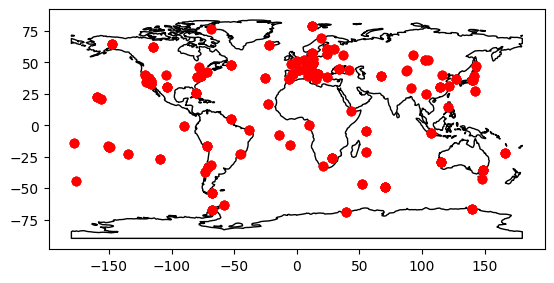

In [45]:
# library used to import the world shape

import geodatasets
from geodatasets import get_path
world = gpd.read_file(get_path("naturalearth.land"))

ax = world.plot(color="white", edgecolor="black")
sites.plot(ax=ax, color="red")


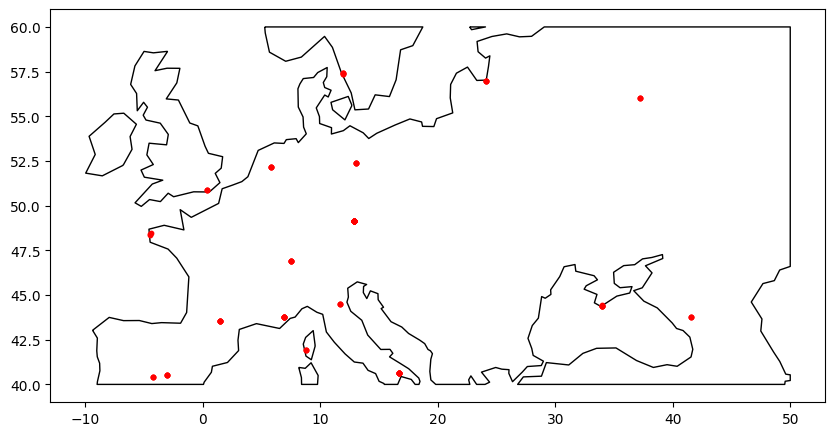

In [46]:
sites['convex_hull'] = sites['geometry'].apply(lambda geom: geom.convex_hull)

hull_gdf = gpd.GeoDataFrame(sites, geometry='convex_hull')
ax = world.clip([-10, 40, 50, 60]).plot(color="white", edgecolor="black", figsize=(10, 8))
hull_gdf.clip([-10, 40, 50, 60]).plot(ax=ax,edgecolor="red", facecolor="blue", figsize=(10, 8), markersize=50)
sites.clip([-10, 40, 50, 60]).plot(ax=ax, color="red", markersize=10)

plt.show()

In [47]:
hull_gdf

,geometry,convex_hull
site_id,,
10002,"MULTIPOINT Z (6.92058 43.75474 1319.30335, 6.9...","POLYGON Z ((6.92077 43.75449 1319.85842, 6.920..."
10003,"MULTIPOINT Z (1.48076 43.56077 207.09635, 1.48...","POLYGON Z ((1.48489 43.54962 210.79597, 1.4812..."
10004,"MULTIPOINT Z (-4.50383 48.40787 104.42082, -4....","POLYGON Z ((-4.49659 48.3805 65.82489, -4.5038..."
10077,"MULTIPOINT Z (8.76246 41.92747 98.24128, 8.762...","POLYGON Z ((8.7627 41.92739 96.80211, 8.76246 ..."
10202,"MULTIPOINT Z (-21.99518 64.15098 95.75501, -21...","POLYGON Z ((-21.95549 64.13879 93.04831, -21.9..."
...,...,...
92301,"MULTIPOINT Z (-134.96492 -23.13026 82.2131, -1...","POLYGON Z ((-134.96483 -23.13035 80.64485, -13..."
92701,"MULTIPOINT Z (166.41006 -22.26983 83.06194, 16...","POLYGON Z ((166.4102 -22.26985 83.04824, 166.4..."
92902,"MULTIPOINT Z (-178.121 -14.30778 85.73272, -17...","POLYGON Z ((-178.12095 -14.3078 84.87284, -178..."


In [48]:
# 2.4. Save the data!
hull_gdf[["convex_hull"]].to_file("site_polygons.shp", driver='ESRI Shapefile')

/var/folders/92/p8d29ssj2sn1wkm3g1hktjdm0000gn/T/ipykernel_60678/2355399182.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  hull_gdf[["convex_hull"]].to_file("site_polygons.shp", driver='ESRI Shapefile')


In [49]:
# 3. Creation of the last SHP (images):

# 3.1. For each site, list the images (between 2022/01/01 and 2022/09/30) that are covering the extent of the site. This is very long!!! Write the information in a <site_id>.json temporary file to be able to restart the script if it fails.

import requests

def request_images(wkt_geometry):
    items = [] # Empty list to store return elements
    # Request
    r = requests.get(
        "https://catalogue.dataspace.copernicus.eu/resto/api/collections/Sentinel2/search.json",
        params={
            "geometry": wkt_geometry,
            "startDate": "2022-01-01T00:00:00.000Z",
            "completionDate": "2022-09-30T23:59:59.999Z",
            "cloudCover": "[0,10]",
            "maxRecords": 20,
            "page": 1,
        }
    )
    # If status_code is not 200, we have an issue
    if r.status_code == 200:
        data = r.json()
        if 'features' in data:
            items += data['features']
    return items

wkt_geometry = 'POLYGON((2.349250 48.8535,2.348703 48.85293,2.350430 48.8524,2.35091 48.8530,2.349250 48.8535))'
images = request_images(wkt_geometry)

#3.Merge all information in one GeoDataFrame.
#Save the data!

In [50]:
#Example of the output after calling the function and using the API request

images

[{'type': 'Feature',
  'id': '095fe993-3316-515b-8ca5-d0a0ca65ddad',
  'geometry': {'type': 'Polygon',
   'coordinates': [[[1.6142723681857, 49.644430073461],
     [3.1352135957809, 49.652643868752],
     [3.1325513271237, 48.664955151836],
     [1.6415462250802, 48.657020775058],
     [1.6142723681857, 49.644430073461]]]},
  'properties': {'collection': 'SENTINEL-2',
   'status': 'ONLINE',
   'license': {'licenseId': 'unlicensed',
    'hasToBeSigned': 'never',
    'grantedCountries': None,
    'grantedOrganizationCountries': None,
    'grantedFlags': None,
    'viewService': 'public',
    'signatureQuota': -1,
    'description': {'shortName': 'No license'}},
   'parentIdentifier': None,
   'title': 'S2B_MSIL2A_20220105T105339_N0301_R051_T31UDQ_20220105T134509.SAFE',
   'description': 'The Copernicus Sentinel-2 mission consists of two polar-orbiting satellites that are positioned in the same sun-synchronous orbit, with a phase difference of 180°. It aims to monitor changes in land surf

<Axes: >

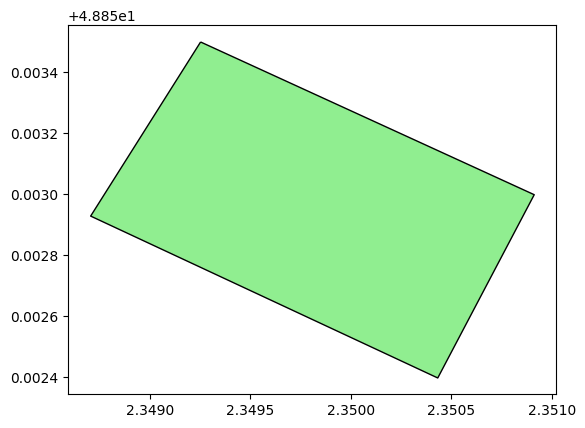

In [51]:
#Example of the polygon used in the function

from shapely import wkt

wkt_geometry = 'POLYGON((2.349250 48.8535,2.348703 48.85293,2.350430 48.8524,2.35091 48.8530,2.349250 48.8535))'
polygon = wkt.loads(wkt_geometry)
gdf = gpd.GeoDataFrame(geometry=[polygon], crs="EPSG:4326")
gdf.plot(edgecolor="black", facecolor="lightgreen")

In [29]:
# List to hold GeoDataFrames
gdf_list = []

for i in range(len(hull_gdf.convex_hull)):
    #print(i)
    images = request_images(hull_gdf.convex_hull[i])
    gdf_list.append(images)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/geopandas/geoseries.py:720: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  val = getattr(super(), mtd)(*args, **kwargs)


In [30]:
#data frame with the list of all images from all sites
df_api = pd.DataFrame(gdf_list)
df_api


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,"{'type': 'Feature', 'id': '3af0b46f-b626-5ad2-...","{'type': 'Feature', 'id': '3fb65452-79f3-59eb-...","{'type': 'Feature', 'id': 'd5962479-5473-52c2-...","{'type': 'Feature', 'id': '63d2aee3-51bf-54c1-...","{'type': 'Feature', 'id': '7b242d90-95f1-545c-...","{'type': 'Feature', 'id': '4f2052d4-d6ac-5195-...","{'type': 'Feature', 'id': '85c55d3b-4e52-58d7-...","{'type': 'Feature', 'id': '661c56eb-11d7-563f-...","{'type': 'Feature', 'id': '4021ee82-392a-5d70-...","{'type': 'Feature', 'id': '2f03020c-f78d-5149-...","{'type': 'Feature', 'id': '74f30e2d-41d9-5861-...","{'type': 'Feature', 'id': 'd4cc8ae1-b424-5c16-...","{'type': 'Feature', 'id': '4f48287e-70d9-5579-...","{'type': 'Feature', 'id': '8cf16d08-15cc-5fb0-...","{'type': 'Feature', 'id': '4732274e-7d5b-5fd7-...","{'type': 'Feature', 'id': '5d763ad9-e90e-5309-...","{'type': 'Feature', 'id': '4df106ad-02c2-557f-...","{'type': 'Feature', 'id': '898834b1-c526-5945-...","{'type': 'Feature', 'id': '3847d120-534d-5c71-...","{'type': 'Feature', 'id': '67b7d181-f868-477a-..."
1,"{'type': 'Feature', 'id': '4bdb01e7-e4a1-5279-...","{'type': 'Feature', 'id': '09fffb76-2553-56d4-...","{'type': 'Feature', 'id': '8029a510-58d1-4d28-...","{'type': 'Feature', 'id': '122226e9-8172-535f-...","{'type': 'Feature', 'id': 'e6568fcb-4cad-5787-...","{'type': 'Feature', 'id': 'c1c112a5-7943-491f-...","{'type': 'Feature', 'id': '0fe544ce-2f9f-59f8-...","{'type': 'Feature', 'id': '43e26710-89d6-5b59-...","{'type': 'Feature', 'id': 'eef5be3a-d580-5514-...","{'type': 'Feature', 'id': 'd544e2dd-8730-5029-...","{'type': 'Feature', 'id': '1ad7099f-e4ef-5699-...","{'type': 'Feature', 'id': '84d1bede-4592-5cd5-...","{'type': 'Feature', 'id': '8d2cb599-666f-56f0-...","{'type': 'Feature', 'id': '9c222338-d24d-4ae3-...","{'type': 'Feature', 'id': '81ebf064-9a6a-5025-...","{'type': 'Feature', 'id': 'ec295205-630e-551e-...","{'type': 'Feature', 'id': 'bf37c4c0-1876-5d47-...","{'type': 'Feature', 'id': 'afe07aa6-2814-5d36-...","{'type': 'Feature', 'id': 'f27d6cdc-94c8-592b-...","{'type': 'Feature', 'id': '5420e51f-131d-5ea9-..."
2,"{'type': 'Feature', 'id': '59fdc9ee-d8a0-5f0f-...","{'type': 'Feature', 'id': 'ac71fb64-ce4f-5c8a-...","{'type': 'Feature', 'id': '45f7f344-3a43-57d9-...","{'type': 'Feature', 'id': '47a6f6c9-3c70-5ebe-...","{'type': 'Feature', 'id': 'bf74b458-5152-5772-...","{'type': 'Feature', 'id': '7d5342b7-7902-5a4f-...","{'type': 'Feature', 'id': '2f680482-732f-5913-...","{'type': 'Feature', 'id': '4f9603f0-a470-598b-...","{'type': 'Feature', 'id': 'f67edc8b-b0c8-5b06-...","{'type': 'Feature', 'id': '5cc7e7ae-e16d-57be-...","{'type': 'Feature', 'id': '24f87785-959d-5ff3-...","{'type': 'Feature', 'id': '63140013-61bc-5b74-...","{'type': 'Feature', 'id': 'c98cef7e-bd0d-5fb5-...","{'type': 'Feature', 'id': 'c6b9f1a2-51fd-53bf-...","{'type': 'Feature', 'id': '44997ebc-feb2-5ef7-...","{'type': 'Feature', 'id': '01ef8e8e-d614-5d12-...","{'type': 'Feature', 'id': '0eedf788-506b-50a2-...","{'type': 'Feature', 'id': 'eeb84549-1732-53ef-...","{'type': 'Feature', 'id': '8aa1db28-2a45-544a-...","{'type': 'Feature', 'id': 'f83947ed-9759-5eaa-..."
3,"{'type': 'Feature', 'id': '8d82b66f-e050-57e4-...","{'type': 'Feature', 'id': '791b2eb1-2198-596f-...","{'type': 'Feature', 'id': 'f0c755e1-1d8e-53a4-...","{'type': 'Feature', 'id': '23e5ada1-f4d8-5298-...","{'type': 'Feature', 'id': 'a3dfdc6f-7d9c-591b-...","{'type': 'Feature', 'id': '27448659-f200-5c2d-...","{'type': 'Feature', 'id': '2d176f42-b5fd-5222-...","{'type': 'Feature', 'id': 'e95cb16d-0326-5a52-...","{'type': 'Feature', 'id': '399b877d-553a-5483-...","{'type': 'Feature', 'id': '9f15eb32-45ac-51ac-...","{'type': 'Feature', 'id': '9f9cb7a4-ca32-5848-...","{'type': 'Feature', 'id': '93e08edb-ac51-584a-...","{'type': 'Feature', 'id': 'a8593a90-cb28-5104-...","{'type': 'Feature', 'id': '0e5e5622-2c9a-53c9-...","{'type': 'Feature', 'id': '8a61d12b-36ac-5527-...","{'type': 'Feature', 'id': '431eedfa-4729

In [52]:
# convert data frame in geodata frame 

gdfapi = gpd.GeoDataFrame(df_api)


In [75]:
# save the data

gdfapi.to_file("sat_img.shp")

TypeError: object of type 'int' has no len()